<a href="https://colab.research.google.com/github/boganast2206/stat_pract/blob/main/homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problem 1
Implement serial test and apply to a `samples`

In [36]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m
rng.current = 1


def serial_chi2(samples, d=2, k=10, plot_pairs=True):
    samples = np.asarray(samples, dtype=float)

    n = len(samples) // d
    if n < 1:
        raise ValueError(f"введи больше чисел пж")

    data = samples[:n * d].reshape(n, d)

    bins = [np.linspace(0.0, 1.0, k + 1)] * d
    obs, _ = np.histogramdd(data, bins=bins)
    obs = obs.ravel()

    exp = np.full(k**d, n / (k**d))

    chi2_stat = ((obs - exp) ** 2 / exp).sum()
    dof = k**d - 1
    pvalue= stats.chi2.sf(chi2_stat, dof)
    return chi2_stat, pvalue

samples = [rng() for _ in range(1000)]

chi2_2, p_2 = serial_chi2(samples, d=2, k=10, plot_pairs=True)
print("d=2 -> chi2 =", chi2_2, ", pvalue =", p_2)

chi2_10, p_10 = serial_chi2(samples, d=10, k=2, plot_pairs=False)
print("d=10 -> chi2 =", chi2_10, ", pvalue =", p_10)

d=2 -> chi2 = 114.39999999999999 , pvalue = 0.1380441495447643
d=10 -> chi2 = 1005.9200000000001 , pvalue = 0.642431220709757


### Problem 2*
Implement permutation test and apply to a `samples`

In [44]:
import numpy as np
from scipy import stats

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m
rng.current = 1


def chi2_uniform(samples, k=10):
    samples = np.asarray(samples, dtype=float)
    n = len(samples)

    bins = np.linspace(0.0, 1.0, k + 1)
    obs, _ = np.histogram(samples, bins=bins)
    exp = np.full(k, n / k)

    chi2_stat = ((obs - exp) ** 2 / exp).sum()
    dof = k - 1
    pvalue = stats.chi2.sf(chi2_stat, dof)

    return chi2_stat, pvalue


samples = [rng() for _ in range(1000)]

chi2_stat, pval = chi2_uniform(samples, k=10)
print("chi2 =", chi2_stat, "pvalue =", pval)

chi2 = 10.059999999999999 pvalue = 0.345649753651346


### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

хороший RNG
тест Колмогорова-Смирнова: p-value = 0.0770 - ok
хи-квадрат тест:          p-value = 0.0881 - ok
serial test:              p-value = 0.8716 - ok

плохой RNG
тест Колмогорова-Смирнова: p-value = 0.0278 - not ok
хи-квадрат тест:          p-value = 0.0470 - not ok
serial test:              p-value = 0.0000 - not ok



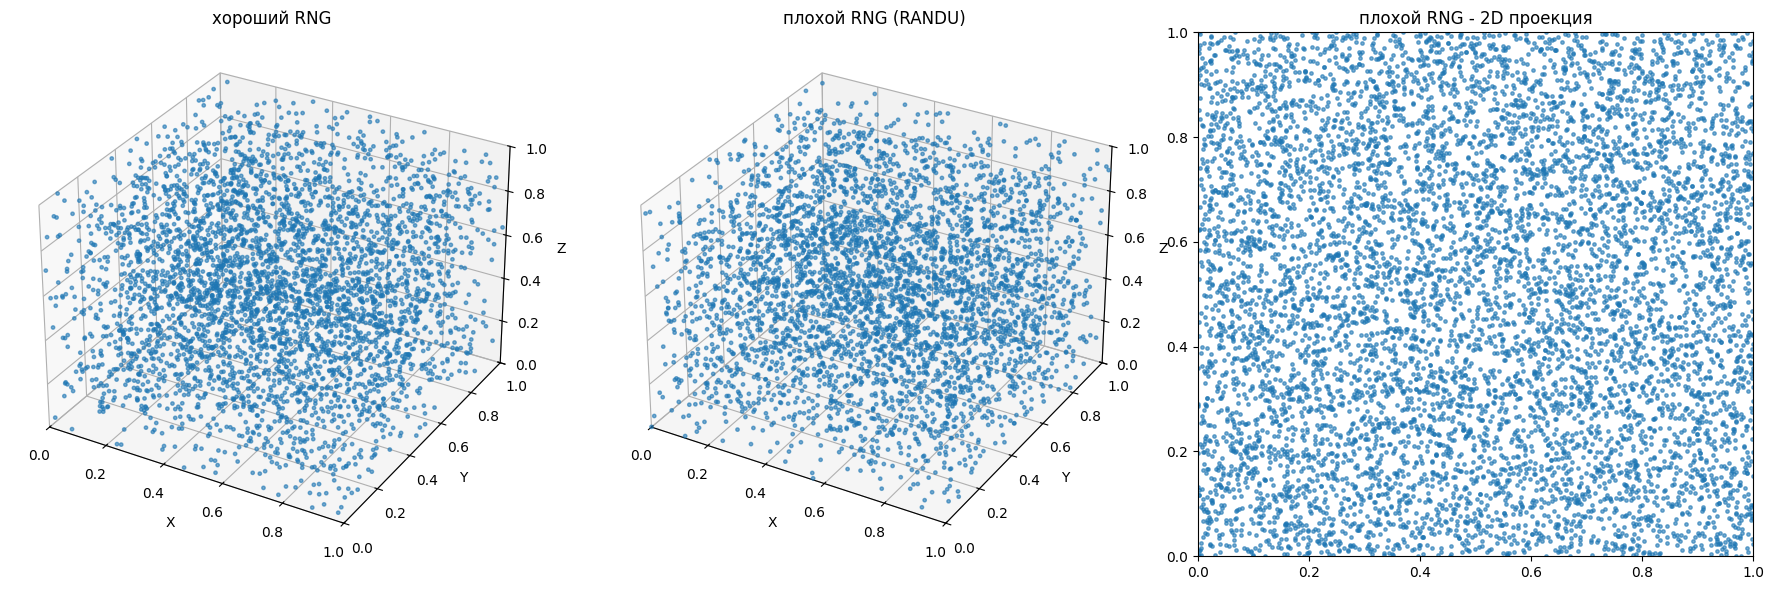

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D

def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m

rng_bad.current = 1

def sample_bad(n, seed=1):
    rng_bad.current = seed
    return np.array([rng_bad() for _ in range(n)], dtype=float)

def sample_good(n, seed=12345):
    return np.random.default_rng(seed).random(n)

def ks_test_u01(x):
    return stats.kstest(x, "uniform")

def chi2_test_1d_u01(x, k=20):
    edges = np.linspace(0.0, 1.0, k + 1)
    obs, _ = np.histogram(x, bins=edges)
    exp = np.full(k, len(x) / k, dtype=float)
    return stats.chisquare(obs, exp)

def serial_test_3d_chi2(x, m=12):

    x = np.asarray(x)
    n = len(x) // 3
    triples = x[:3*n].reshape(n, 3)

    edges = [np.linspace(0.0, 1.0, m + 1)] * 3
    H, _ = np.histogramdd(triples, bins=edges)
    obs = H.ravel()
    exp = np.full_like(obs, n / (m**3), dtype=float)
    return stats.chisquare(obs, exp)

def ok_not_ok(p, alpha=0.05):
    return "ok" if p >= alpha else "not ok"

def print_block(title, ks, chi2, serial, alpha=0.05):
    print(title)
    print(f"тест Колмогорова-Смирнова: p-value = {ks.pvalue:.4f} - {ok_not_ok(ks.pvalue, alpha)}")
    print(f"хи-квадрат тест:          p-value = {chi2.pvalue:.4f} - {ok_not_ok(chi2.pvalue, alpha)}")
    print(f"serial test:              p-value = {serial.pvalue:.4f} - {ok_not_ok(serial.pvalue, alpha)}")
    print()


n = 30000
alpha = 0.05

good = sample_good(n, seed=12345)
bad = sample_bad(n, seed=1)

ks_g = ks_test_u01(good)
chi_g = chi2_test_1d_u01(good, k=20)
ser_g = serial_test_3d_chi2(good, m=12)

ks_b = ks_test_u01(bad)
chi_b = chi2_test_1d_u01(bad, k=20)
ser_b = serial_test_3d_chi2(bad, m=12)

print_block("хороший RNG", ks_g, chi_g, ser_g, alpha=alpha)
print_block("плохой RNG",  ks_b, chi_b, ser_b, alpha=alpha)

NPTS_3D = 4000
NPTS_2D = 8000

g3 = good[:3*(NPTS_3D)].reshape(-1, 3)
b3 = bad[:3*(NPTS_3D)].reshape(-1, 3)

fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.scatter(g3[:, 0], g3[:, 1], g3[:, 2], s=6, alpha=0.6)
ax1.set_title("хороший RNG")
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.set_zlim(0, 1)

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.scatter(b3[:, 0], b3[:, 1], b3[:, 2], s=6, alpha=0.6)
ax2.set_title("плохой RNG (RANDU)")
ax2.set_xlabel("X"); ax2.set_ylabel("Y"); ax2.set_zlabel("Z")
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.set_zlim(0, 1)

ax3 = fig.add_subplot(1, 3, 3)
ax3.scatter(bad[:NPTS_2D], bad[1:NPTS_2D+1], s=6, alpha=0.6)
ax3.set_title("плохой RNG - 2D проекция")
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

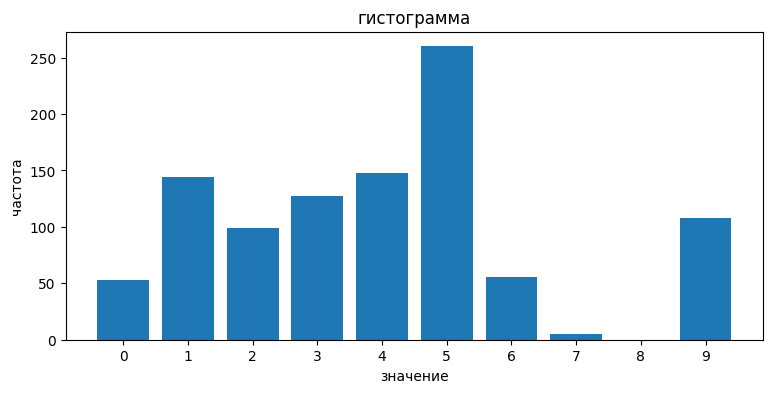


теоретические вероятности:
0: 0.059731
1: 0.149328
2: 0.083126
3: 0.119462
4: 0.154306
5: 0.268790
6: 0.055251
7: 0.009955
8: 0.000498
9: 0.099552

эмпирические вероятности:
0: 0.053000
1: 0.144000
2: 0.099000
3: 0.127000
4: 0.148000
5: 0.260000
6: 0.056000
7: 0.005000
8: 0.000000
9: 0.108000


In [17]:
import numpy as np
import matplotlib.pyplot as plt

digits = np.arange(10)
weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31,
                    0.54, 0.111, 0.02, 0.001, 0.2], dtype=float)

p = weights / weights.sum()

def sample_discrete(n, values, probs, seed=42):
    rng = np.random.default_rng(seed)

    values = np.asarray(values)
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()

    cdf = np.cumsum(probs)
    samples = np.empty(n, dtype=int)

    for i in range(n):
        u = rng.random()
        j = 0
        while u > cdf[j]:
            j += 1
        samples[i] = values[j]

    return samples


n = 1000
samples = sample_discrete(n, digits, p, seed=1)

counts = np.bincount(samples, minlength=10)

plt.figure(figsize=(9, 4))
plt.bar(digits, counts)
plt.xticks(digits)
plt.xlabel("значение")
plt.ylabel("частота")
plt.title("гистограмма")
plt.show()

emp = counts / n

print("\nтеоретические вероятности:")
for d, prob in zip(digits, p):
    print(f"{d}: {prob:.6f}")

print("\nэмпирические вероятности:")
for d, fr in enumerate(emp):
    print(f"{d}: {fr:.6f}")

### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

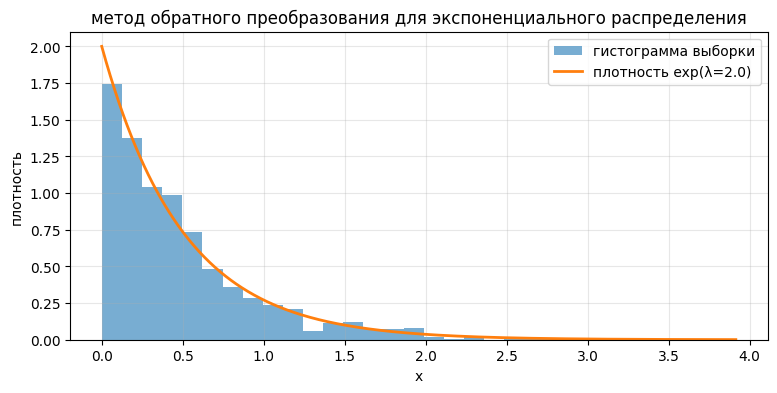

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def rng():
    return np.random.default_rng().random()

lam = 2.0
n = 1000

u = np.array([rng() for _ in range(n)], dtype=float)

x = -np.log(1.0 - u) / lam

plt.figure(figsize=(9, 4))
plt.hist(x, bins=30, density=True, alpha=0.6, label="гистограмма выборки")

xx = np.linspace(0, x.max()*1.05, 600)
pdf = lam * np.exp(-lam * xx)

plt.plot(xx, pdf, linewidth=2, label=f"плотность exp(λ={lam})")

plt.title("метод обратного преобразования для экспоненциального распределения")
plt.xlabel("x")
plt.ylabel("плотность")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

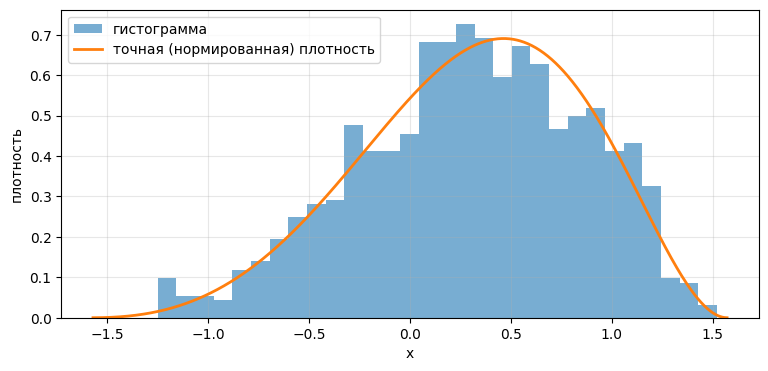

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

a = -np.pi/2
b =  np.pi/2

def f_unnorm(x):
    return np.exp(x) * (np.cos(x) ** 2)

Z, _ = integrate.quad(lambda t: f_unnorm(t), a, b)
def f_exact(x):
    return f_unnorm(x) / Z
grid = np.linspace(a, b, 200_000)
f_max = float(np.max(f_unnorm(grid)))

def accept_reject(n, seed=1):
    rng = np.random.default_rng(seed)
    samples = []
    trials = 0
    while len(samples) < n:
        trials += 1
        x = rng.uniform(a, b)
        u = rng.random()
        if u <= f_unnorm(x) / f_max:
            samples.append(x)
    return np.array(samples), trials

n = 1000
samples, trials = accept_reject(n, seed=1)
accept_rate = n / trials


xx = np.linspace(a, b, 800)

plt.figure(figsize=(9, 4))
plt.hist(samples, bins=30, density=True, alpha=0.6, label="гистограмма")
plt.plot(xx, f_exact(xx), linewidth=2, label="точная (нормированная) плотность")
plt.xlabel("x")
plt.ylabel("плотность")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Coordinate transformation method

The accept-reject method may in some cases be inefficient and require too many sample points. An alternative is to try to find a coordinate transformation that converts a simple area (from which it is easy to sample, for example, a unit square) into the required area, but preserves the area ratio (why?).

Пусть точка $(u,v)$ равномерно распределена в области $S$, то есть  

$$
p_S(u,v) = 1.
$$

Рассмотрим преобразование координат  

$$
(x,y) = \varphi(u,v).
$$

По формуле замены переменных плотность в новых координатах равна  

$$
p(x,y) = \frac{p_S(u,v)}{|J(u,v)|}
       = \frac{1}{|J(u,v)|},
$$

где $J(u,v)$ — якобиан преобразования.

---

Чтобы распределение $(x,y)$ также было равномерным, плотность $p(x,y)$ должна быть постоянной.  

Это выполняется тогда и только тогда, когда  

$$
|J(u,v)| = \text{const}.
$$

В этом случае преобразование масштабирует все площади в одинаковое число раз,  
поэтому равномерность распределения сохраняется  
(меняется только значение плотности, которое затем можно нормировать).

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

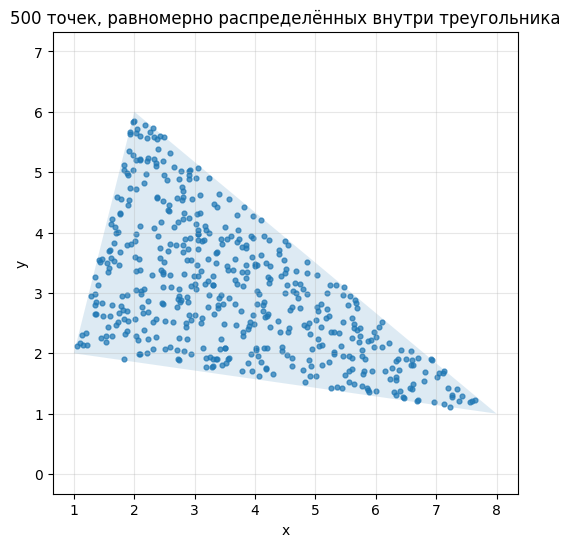

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

A = np.array([1.0, 2.0])
B = np.array([2.0, 6.0])
C = np.array([8.0, 1.0])

n = 500

u = np.random.rand(n)
v = np.random.rand(n)
r = np.sqrt(u)

wA = 1 - r
wB = r * (1 - v)
wC = r * v

points = wA[:, None] * A + wB[:, None] * B + wC[:, None] * C

fig = plt.figure(figsize=(6, 6))

polygon = Polygon(xy=np.vstack([A, B, C]), closed=True)
plt.gca().add_collection(PatchCollection([polygon], alpha=0.15))

plt.scatter(points[:, 0], points[:, 1], s=12, alpha=0.7)
plt.title("500 точек, равномерно распределённых внутри треугольника")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

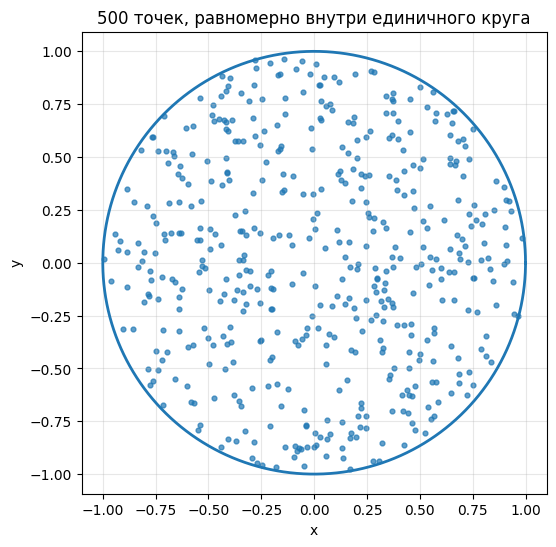

In [29]:
import numpy as np
import matplotlib.pyplot as plt

n = 500
rng = np.random.default_rng(42)

u = rng.random(n)
v = rng.random(n)

r = np.sqrt(u)
theta = 2 * np.pi * v

x = r * np.cos(theta)
y = r * np.sin(theta)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=12, alpha=0.7)

t = np.linspace(0, 2*np.pi, 400)
plt.plot(np.cos(t), np.sin(t), linewidth=2)

plt.title("500 точек, равномерно внутри единичного круга")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

выборочное среднее: [4.25483191 7.15681175]
точное среднее:      [4. 7.]

выборочная ковариационная матрица:
 [[20.60284698 -4.04995056]
 [-4.04995056 37.04336151]]

точная ковариационная матрица:
 [[20. -4.]
 [-4. 40.]]


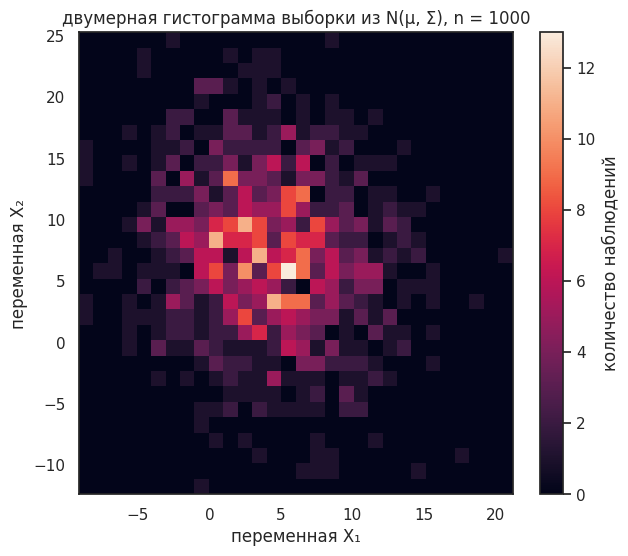

In [35]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def marsaglia_polar(n):

    out = np.empty(n)
    k = 0
    while k < n:
        u = 2*np.random.rand() - 1
        v = 2*np.random.rand() - 1
        s = u*u + v*v
        if s <= 0 or s >= 1:
            continue
        m = np.sqrt(-2*np.log(s)/s)
        out[k] = u*m
        if k + 1 < n:
            out[k+1] = v*m
        k += 2
    return out

mu = np.array([4.0, 7.0])
Sigma = np.array([[20.0, -4.0],
                  [-4.0, 40.0]])

n = 1000

Z = marsaglia_polar(2*n).reshape(n, 2)

L = np.linalg.cholesky(Sigma)
X = mu + Z @ L.T

print("выборочное среднее:", X.mean(axis=0))
print("точное среднее:     ", mu)
print("\nвыборочная ковариационная матрица:\n", np.cov(X, rowvar=False))
print("\nточная ковариационная матрица:\n", Sigma)

plt.figure(figsize=(7, 6))
plt.hist2d(X[:, 0], X[:, 1], bins=30)
plt.xlabel("переменная X₁")
plt.ylabel("переменная X₂")
plt.title("двумерная гистограмма выборки из N(μ, Σ), n = 1000")
plt.colorbar(label="количество наблюдений")
plt.show()